#**RED CNN** Implementation  - with **Mayo** dataset
Inspired by the Github Repository SSinyu/RED-CNN (for Mayo dataset), edited by Nili Aron and Shoham Marom.
Python code for training (with validation) + testing RED-CNN on Mayo data set.
Organized Documentation is in READ-ME.
Every cell mentions the original code file(s) from SSinyu/RED-CNN repo.

Please run all cells by order. Visualization of RED CNN Implementation taken from the SSinyu/RED-CNN repo:

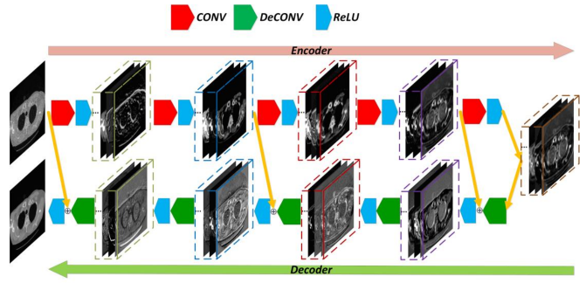

#### **Cell 0:** Upload data from drive and organize it properly



In [ ]:
# Download the single zip file using its ID
!gdown --id 1G6EE1aNvP-c4bi8cUGKkP2o2313-NvgY -O 3mmB30.zip

# Unzip the contents into your Colab environment and remove the zip
!unzip -q 3mmB30.zip -d 3mmB30
!rm 3mmB30.zip

!mv /content/3mmB30/*3mm*B30*/L* /content/3mmB30/
!rm -r /content/3mmB30/*3mm*B30*

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1G6EE1aNvP-c4bi8cUGKkP2o2313-NvgY
From (redirected): https://drive.google.com/uc?id=1G6EE1aNvP-c4bi8cUGKkP2o2313-NvgY&confirm=t&uuid=f2810ba2-6950-4516-9c2b-97755b220994
To: /content/3mmB30.zip
100% 1.47G/1.47G [00:18<00:00, 79.0MB/s]


#### **Cell** **1**: Improts  and Installing


In [ ]:
!pip install pydicom

import os
import time
import argparse
from glob import glob
from collections import OrderedDict
from math import exp

import numpy as np
import pydicom
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable
from torch.backends import cudnn

from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR, LinearLR, SequentialLR #New: adding learning rate schedulers.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.4 MB/s eta 0:00:00


#### **Cell 2:** Model class description, including all layers and feed forward method.
*   **Encoder**: first 5 conv layers
*   **Decoder**: last 5 deconv layers, including skip connections.

Every Conv/Deconv layer, starting from the second, works on 96 feature channels in a 5x5 kernel, as decided emprically by the original creatores of RED CNN, since it captures enough details without making the model too heavy.

Full interpretation in the report.

**Based on:** networks.py

In [ ]:
class RED_CNN(nn.Module):
    def __init__(self, out_ch=96):
        super(RED_CNN, self).__init__()
        # Encoder:
        self.conv1 = nn.Conv2d(1, out_ch, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.conv4 = nn.Conv2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.conv5 = nn.Conv2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        # Decoder:
        self.tconv1 = nn.ConvTranspose2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.tconv2 = nn.ConvTranspose2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.tconv3 = nn.ConvTranspose2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.tconv4 = nn.ConvTranspose2d(out_ch, out_ch, kernel_size=5, stride=1, padding=0)
        self.tconv5 = nn.ConvTranspose2d(out_ch, 1, kernel_size=5, stride=1, padding=0)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Encoder
        residual_1 = x
        out = self.relu(self.conv1(x))
        out = self.relu(self.conv2(out))
        residual_2 = out
        out = self.relu(self.conv3(out))
        out = self.relu(self.conv4(out))
        residual_3 = out
        out = self.relu(self.conv5(out))
        # Decoder
        out = self.tconv1(out)
        out += residual_3
        out = self.tconv2(self.relu(out))
        out = self.tconv3(self.relu(out))
        out += residual_2
        out = self.tconv4(self.relu(out))
        out = self.tconv5(self.relu(out))
        out += residual_1
        out = self.relu(out)
        return out

#### **Cell 3:** Metrics for Evaluting the net (image) output.
Contain primary function "compute_measure" that evaluating the output using different methods, such as:

1.   **PSNR**: Measure Peak Signal to Noise Ratio. Peak Signal is (data_range)^2. data_range = trunc_max - trunc_min. Noise power is the average power of the error signal. Higher PSNR expected from the net output.
2.   **SSIM**: Measure the average Structural Similarity Index (composed of 3 comparison kriteria: luminance, contrast, structure). Higher SSIM expected from the net output.
3.   **RMSE**: Measure the Root Mean Square Error between GT and input/output images. Less error expected from the net output.

**Based on:** measure.py

In [ ]:
# ----
# Main Evaluating func:
# ----
def compute_measure(x, y, pred, data_range):
    original_psnr = compute_PSNR(x, y, data_range)
    original_ssim = compute_SSIM(x, y, data_range)
    original_rmse = compute_RMSE(x, y)
    pred_psnr = compute_PSNR(pred, y, data_range)
    pred_ssim = compute_SSIM(pred, y, data_range)
    pred_rmse = compute_RMSE(pred, y)
    return (original_psnr, original_ssim, original_rmse), (pred_psnr, pred_ssim, pred_rmse)
# ----
# 1. RMSE
# ----
def compute_MSE(img1, img2):
    return ((img1 - img2) ** 2).mean()

def compute_RMSE(img1, img2):
    if type(img1) == torch.Tensor:
        return torch.sqrt(compute_MSE(img1, img2)).item()
    else:
        return np.sqrt(compute_MSE(img1, img2))
# ----
# 2. PSNR
# ----
def compute_PSNR(img1, img2, data_range):
    if type(img1) == torch.Tensor:
        mse_ = compute_MSE(img1, img2)
        return 10 * torch.log10((data_range ** 2) / mse_).item()
    else:
        mse_ = compute_MSE(img1, img2)
        return 10 * np.log10((data_range ** 2) / mse_)
# ----
# 3. SSIM
# ----
def compute_SSIM(img1, img2, data_range, window_size=11, channel=1, size_average=True):
    if len(img1.size()) == 2:
        shape_ = img1.shape[-1]
        img1 = img1.view(1,1,shape_ ,shape_ )
        img2 = img2.view(1,1,shape_ ,shape_ )
    window = create_window(window_size, channel)
    window = window.type_as(img1)

    mu1 = F.conv2d(img1, window, padding=window_size//2)
    mu2 = F.conv2d(img2, window, padding=window_size//2)
    mu1_sq, mu2_sq = mu1.pow(2), mu2.pow(2)
    mu1_mu2 = mu1*mu2

    sigma1_sq = F.conv2d(img1*img1, window, padding=window_size//2) - mu1_sq
    sigma2_sq = F.conv2d(img2*img2, window, padding=window_size//2) - mu2_sq
    sigma12 = F.conv2d(img1*img2, window, padding=window_size//2) - mu1_mu2

    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2

    ssim_map = ((2*mu1_mu2+C1)*(2*sigma12+C2)) / ((mu1_sq+mu2_sq+C1)*(sigma1_sq+sigma2_sq+C2)) # final term - all 3 comps combined
    if size_average:
        return ssim_map.mean().item()
    else:
        return ssim_map.mean(1).mean(1).mean(1).item()

def gaussian(window_size, sigma):
    gauss = torch.Tensor([exp(-(x - window_size // 2) ** 2 / float(2 * sigma ** 2)) for x in range(window_size)])
    return gauss / gauss.sum()

def create_window(window_size, channel):
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = Variable(_2D_window.expand(channel, 1, window_size, window_size).contiguous())
    return window

#### **Cell 4:** Pre-Processing the data.
Process and organize the images:
*   Converting to HU units and normalize data
*   Create 3D slices vectors
*   Find every slice exact thickness and save it to the metadata
*   Convert all DCIM images to numpy format

>**User note:**

A. If one desires to change paths, please fill in the requested paths:
1.   '--data_path' - location of 3mmB30 folder
2.   '--save_path' - location for new numpy arrayes

B. If one desires to run in terminal rather than in Google Colab, please uncomment: `args = parser.parse_args()` and comment: `args = parser.parse_args(args=[])`

**Based on**: prep.py

In [ ]:
def save_dataset(args):
    "convert given images to numpy arrays and save them"
    # Check if the directory specified for saving the processed numpy arrays exists
    if not os.path.exists(args.save_path):
        os.makedirs(args.save_path)
        print('Create path : {}'.format(args.save_path))

    patients_list = sorted([d for d in os.listdir(args.data_path) if 'zip' not in d and d.startswith('L')])
    print(patients_list)
    for p_ind, patient in enumerate(patients_list):
        patient_input_path = os.path.join(args.data_path, patient,
                                          "quarter_{}mm".format(args.mm))
        print(patient_input_path)

        patient_target_path = os.path.join(args.data_path, patient,
                                           "full_{}mm".format(args.mm))

        for path_ in [patient_input_path, patient_target_path]:
            full_pixels = get_pixels_hu(load_scan(path_))
            for pi in range(len(full_pixels)):
                io = 'input' if 'quarter' in path_ else 'target'
                f = normalize_(full_pixels[pi], args.norm_range_min, args.norm_range_max)
                f_name = '{}_{}_{}.npy'.format(patient, pi, io)
                np.save(os.path.join(args.save_path, f_name), f)

        printProgressBar(p_ind, len(patients_list),
                         prefix="save image ..",
                         suffix='Complete', length=25)
        print(' ')

def load_scan(path):
    """referred from https://www.kaggle.com/gzuidhof/full-preprocessing-tutorial.
    Extract slice thickness from every file"""
    # Read DICOM files from folder, store them in list
    # (os.listdir gets filenames, pydicom.dcmread opens and parses each file)
    slices = [pydicom.dcmread(os.path.join(path, s)) for s in os.listdir(path)]

    # Sort slices into their correct anatomical 3D sequence
    # ImagePositionPatient[2] extracts the physical Z-axis coordinate of the scan
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    # Mathematically calculate the real physical distance between image slices
    try:
        # Primary method: calculate absolute difference between the Z-coordinates of slice 0 and slice 1
        slice_thickness = np.abs(slices[0].ImagePositionPatient[2] - slices[1].ImagePositionPatient[2])
    except:
        # Fallback method: if the machine didn't record ImagePositionPatient, try SliceLocation instead
        slice_thickness = np.abs(slices[0].SliceLocation - slices[1].SliceLocation)

    # Overwrite the default thickness metadata on every slice
    # (the built-in DICOM SliceThickness tag is often missing/unreliable)
    for s in slices:
        s.SliceThickness = slice_thickness

    # Return sorted, corrected list of DICOM objects
    return slices

def get_pixels_hu(slices):
    # referred from https://www.kaggle.com/gzuidhof/full-preprocessing-tutorial

    # Extract raw 2D pixel arrays from each DICOM slice and stack them together to create a single 3D NumPy volume.
    image = np.stack([s.pixel_array for s in slices])

    # Convert the pixel values to 16-bit integers.
    image = image.astype(np.int16)

    # replace pixels that had artificial values with air (HU=0) pixels.
    image[image == -2000] = 0

    # Convert raw machine pixels to standard HU.
    # formula: HU = (Raw_Pixel_Value * Rescale_Slope) + Rescale_Intercept
    for slice_number in range(len(slices)):
        # Extract slope and intercept metadata attached to slice
        intercept = slices[slice_number].RescaleIntercept
        slope = slices[slice_number].RescaleSlope
        if slope != 1:
            image[slice_number] = slope * image[slice_number].astype(np.float64)
            image[slice_number] = image[slice_number].astype(np.int16)
        image[slice_number] += np.int16(intercept)
    # Return final 3D volume, accurately representing tissue density in HU
    return np.array(image, dtype=np.int16)


def normalize_(image, MIN_B=-1024.0, MAX_B=3072.0):
   image = (image - MIN_B) / (MAX_B - MIN_B)
   return image


def printProgressBar(iteration, total, prefix='', suffix='', decimals=1, length=100, fill=' '):
    # referred from https://gist.github.com/snakers4/91fa21b9dda9d055a02ecd23f24fbc3d
    percent = ("""{0:.""" + str(decimals) + """f}""").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '=' * (length - filledLength)
    print('\r%s |%s| %s%% %s' % (prefix, bar, percent, suffix), end='\r')
    if iteration == total:
        print()

# This block only runs if this script is executed directly
if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    # Define where the raw DICOM files are located
    parser.add_argument('--data_path', type=str, default='./content/3mmB30')

    # Define where the processed 3D NumPy arrays (.npy files) should be saved
    parser.add_argument('--save_path', type=str, default='./npy_img/')

    # Define which patient ID to hold out from training to use for testing/evaluation later
    parser.add_argument('--test_patient', type=str, default='L506')

    # Define which patient ID to hold out from training to use for validation later
    parser.add_argument('--valid_patient', type=str, default='L109')

    # Target slice thickness in millimeters (mm) to standardize the 3D volume resolution
    parser.add_argument('--mm', type=int, default=3)

    # Define clipping range for HU; tissue below -1024 HU (air)
    # or above 3072 HU (dense bone/metal) be clipped before normalized to [0,1].
    parser.add_argument('--norm_range_min', type=float, default=-1024.0)
    parser.add_argument('--norm_range_max', type=float, default=3072.0)

    # For terminal: Parse provided arguments, store them in 'args'
    # args = parser.parse_args()

    # To match Google Colab environment setup -
    # loads all 'default' values defined above into 'args':
    args = parser.parse_args(args=[])
    args.data_path = "/content/3mmB30"
    args.save_path = "/content/npy_img"

    # Trigger the main preprocessing pipeline using these settings
    save_dataset(args)

Create path : /content/npy_img
['L067', 'L096', 'L109', 'L143', 'L192', 'L286', 'L291', 'L310', 'L333', 'L506']
/content/3mmB30/L067/quarter_3mm
 
/content/3mmB30/L096/quarter_3mm
 
/content/3mmB30/L109/quarter_3mm
 
/content/3mmB30/L143/quarter_3mm
 
/content/3mmB30/L192/quarter_3mm
 
/content/3mmB30/L286/quarter_3mm
 
/content/3mmB30/L291/quarter_3mm
 
/content/3mmB30/L310/quarter_3mm
 
/content/3mmB30/L333/quarter_3mm
 
/content/3mmB30/L506/quarter_3mm
 


#### **Cell 5:** Definition of Dataset Class and DataLoader object
*   **ct_dataset**: Class that holds all the patches of all the images of all the chosen patients (after desired transform), for some mode (train test or validition).
*   **data_loader**: Creating batches and shuffling the data.




**Based on**: loader.py

In [ ]:
class ct_dataset(Dataset):
    """The MAYO data set composed of 10 subjects. According to current main,
    9 of them for train.
    """
    def __init__(self, mode, load_mode, saved_path, test_patient, valid_patient, patch_n=None, patch_size=None, transform=None):
        assert mode in ['train', 'test', 'valid'], "mode is 'train', 'test' or 'valid'"
        assert load_mode in [0,1], "load_mode is 0 (slow) or 1 (fast, if RAM can spare 10GB)"

        # Fetch files matching the requested mode
        input_path = sorted(glob(os.path.join(saved_path, '*_input.npy')))
        target_path = sorted(glob(os.path.join(saved_path, '*_target.npy')))
        self.load_mode = load_mode
        self.patch_n = patch_n # how many patches to take from single image
        self.patch_size = patch_size # if none, patch is entire image
        self.transform = transform # pre-proccessing or augmentation function

        if mode == 'train':
            input_ = [f for f in input_path if test_patient not in f and valid_patient not in f]
            target_ = [f for f in target_path if test_patient not in f and valid_patient not in f]
        elif mode == 'valid':
            input_ = [f for f in input_path if valid_patient in f]
            target_ = [f for f in target_path if valid_patient in f]
        else: # test
            input_ = [f for f in input_path if test_patient in f]
            target_ = [f for f in target_path if test_patient in f]

        if load_mode == 0:
            self.input_ = input_
            self.target_ = target_
        else:
            self.input_ = [np.load(f) for f in input_]
            self.target_ = [np.load(f) for f in target_]

    def __len__(self): # size of data (num of pairs (input, target))
        return len(self.target_)

    def __getitem__(self, idx): # returns all n patches of certain pair (input image, gt image)
        input_img, target_img = self.input_[idx], self.target_[idx]
        if self.load_mode == 0:
            input_img, target_img = np.load(input_img), np.load(target_img)

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        if self.patch_size:
            input_patches, target_patches = get_patch(input_img, target_img, self.patch_n, self.patch_size)
            return (input_patches, target_patches)
        else:
            return (input_img, target_img)

def get_patch(full_input_img, full_target_img, patch_n, patch_size):
    assert full_input_img.shape == full_target_img.shape
    patch_input_imgs = []
    patch_target_imgs = []
    h, w = full_input_img.shape
    new_h, new_w = patch_size, patch_size
    for _ in range(patch_n):
        top = np.random.randint(0, h-new_h) # each patch must start in valid place (not too much close to the edge)
        left = np.random.randint(0, w-new_w)
        patch_input_img = full_input_img[top:top+new_h, left:left+new_w]
        patch_target_img = full_target_img[top:top+new_h, left:left+new_w]
        patch_input_imgs.append(patch_input_img)
        patch_target_imgs.append(patch_target_img)
    return np.array(patch_input_imgs), np.array(patch_target_imgs)

def get_loader(mode='train', load_mode=0, saved_path=None, test_patient='L506', valid_patient='L109',
               patch_n=None, patch_size=None, transform=None, batch_size=32, num_workers=6):
    dataset_ = ct_dataset(mode, load_mode, saved_path, test_patient, valid_patient, patch_n, patch_size, transform)
    data_loader = DataLoader(dataset=dataset_, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    return data_loader

def printProgressBar(iteration, total, prefix='', suffix='', decimals=1, length=100, fill=' '):
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '=' * (length - filledLength)
    print('\r%s |%s| %s%% %s' % (prefix, bar, percent, suffix), end='\r')
    if iteration == total:
        print()

#### **Cell 6:** Definition of Solver Class, manager of all processes:

*   Training
*   Testing
*   Data processing
*   Saving figs and models

**Based on**: solver.py

In [ ]:
class Solver(object):
    def __init__(self, args, data_loader, valid_loader=None):
        """
        The Solver class handles the training and testing loops for the RED-CNN model.
        It manages data loading, model weight saving/loading, learning rate decay,
        loss calculation, and visualization of the results.
        """
        # Operational modes and data pipeline
        self.mode = args.mode
        self.load_mode = args.load_mode
        self.data_loader = data_loader
        self.valid_loader = valid_loader # NEW

        # Device configuration (GPU vs CPU)
        if args.device:
            self.device = torch.device(args.device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Normalization and truncation limits for HU
        self.norm_range_min = args.norm_range_min
        self.norm_range_max = args.norm_range_max
        self.trunc_min = args.trunc_min
        self.trunc_max = args.trunc_max

        # File paths and hardware config
        self.save_path = args.save_path
        self.multi_gpu = args.multi_gpu

        # Training hyperparameters
        self.num_epochs = args.num_epochs
        self.print_iters = args.print_iters
        self.decay_iters = args.decay_iters
        self.save_iters = args.save_iters
        self.test_iters = args.test_iters
        self.result_fig = args.result_fig

        self.patch_size = args.patch_size

        # Initialize
        self.REDCNN = RED_CNN()

        # If multiple GPUs are available, wrap the model in DataParallel to split the workload
        if (self.multi_gpu) and (torch.cuda.device_count() > 1):
            print('Use {} GPUs'.format(torch.cuda.device_count()))
            self.REDCNN = nn.DataParallel(self.REDCNN)
        self.REDCNN.to(self.device)

        self.lr = args.lr
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.REDCNN.parameters(), self.lr)

    def save_model(self, iter_):
        """Saves the model's weights (state_dict) at a specific iteration."""
        f = os.path.join(self.save_path, 'REDCNN_{}iter.ckpt'.format(iter_))
        torch.save(self.REDCNN.state_dict(), f)

    def load_model(self, iter_):
        """Loads saved model weights. Handles multi-GPU formatting issues."""
        f = os.path.join(self.save_path, 'REDCNN_{}iter.ckpt'.format(iter_))
        if self.multi_gpu:
            # When a model is saved using nn.DataParallel, PyTorch adds 'module.'
            # to the beginning of every layer name. This loop removes that prefix
            # so the weights can be loaded correctly.
            state_d = OrderedDict()
            for k, v in torch.load(f):
                n = k[7:] # Skips the first 7 characters ('module.')
                state_d[n] = v
            self.REDCNN.load_state_dict(state_d)
        else:
            # Standard single-GPU loading
            self.REDCNN.load_state_dict(torch.load(f))

    def lr_decay(self):
        """Cuts the learning rate in half. Use to fine-tune the model as it converges."""
        lr = self.lr * 0.5
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def denormalize_(self, image):
        """Converts image tensors back from [0, 1] range to their original scale (HU)."""
        image = image * (self.norm_range_max - self.norm_range_min) + self.norm_range_min
        return image

    def trunc(self, mat):
        """Clips pixel values to ensure they stay within the predefined physical bounds."""
        # truncation used only in test mode so in one hand, the learning wont be affected
        # and in the other hand, in testing it will clip unexpected values.
        mat[mat <= self.trunc_min] = self.trunc_min
        mat[mat >= self.trunc_max] = self.trunc_max
        return mat

    def save_fig(self, x, y, pred, fig_name, original_result, pred_result):
        """Generates and saves a side-by-side comparison image of the input, target, and output."""
        # Convert PyTorch tensors to NumPy arrays for Matplotlib
        x, y, pred = x.numpy(), y.numpy(), pred.numpy()
        f, ax = plt.subplots(1, 3, figsize=(30, 10))
        # Plot Quarter-dose (Input)
        ax[0].imshow(x, cmap=plt.cm.gray, vmin=self.trunc_min, vmax=self.trunc_max)
        ax[0].set_title('Quarter-dose', fontsize=30)
        ax[0].set_xlabel("PSNR: {:.4f}\nSSIM: {:.4f}\nRMSE: {:.4f}".format(original_result[0], original_result[1], original_result[2]), fontsize=20)
        # Plot Prediction (Model Output)
        ax[1].imshow(pred, cmap=plt.cm.gray, vmin=self.trunc_min, vmax=self.trunc_max)
        ax[1].set_title('Result', fontsize=30)
        ax[1].set_xlabel("PSNR: {:.4f}\nSSIM: {:.4f}\nRMSE: {:.4f}".format(pred_result[0], pred_result[1], pred_result[2]), fontsize=20)
        # Plot Full-dose (Ground Truth Target)
        ax[2].imshow(y, cmap=plt.cm.gray, vmin=self.trunc_min, vmax=self.trunc_max)
        ax[2].set_title('Full-dose', fontsize=30)

        # Save to disk and display in the notebook output:
        f.savefig(os.path.join(self.save_path, 'fig', 'result_{}.png'.format(fig_name)))
        plt.show()
        plt.close()

    def train(self):
        """The main training loop."""
        train_losses = []
        epoch_train_losses = []
        valid_losses = []
        self.valid_psnr_deltas = []
        self.valid_ssim_deltas = []
        self.valid_rmse_deltas = []
        total_iters = 0
        start_time = time.time()
        for epoch in range(1, self.num_epochs):
            self.REDCNN.train(True)
            epoch_loss = 0
            # x = low dose input, y = normal dose ground truth
            for iter_, (x, y) in enumerate(self.data_loader):
                total_iters += 1

                # Add a channel dimension (unsqueeze) and move data to the GPU/CPU
                x = x.unsqueeze(0).float().to(self.device)
                y = y.unsqueeze(0).float().to(self.device)

                # If processing in patches rather than full images, reshape the tensors
                if self.patch_size:
                    # for Conv2d, reshapes x to 4D tensor with 1 channel, patch_size × patch_size spatial dimension, automatically computing batch size.
                    x = x.view(-1, 1, self.patch_size, self.patch_size)
                    y = y.view(-1, 1, self.patch_size, self.patch_size)

                pred = self.REDCNN(x)
                loss = self.criterion(pred, y)
                self.REDCNN.zero_grad()
                self.optimizer.zero_grad()

                loss.backward()
                self.optimizer.step()

                loss_val = loss.item()
                train_losses.append(loss_val)
                epoch_loss += loss_val

                if total_iters % self.print_iters == 0:
                    print("STEP [{}], EPOCH [{}/{}], ITER [{}/{}] \nLOSS: {:.8f}, TIME: {:.1f}s".format(
                        total_iters, epoch, self.num_epochs, iter_+1, len(self.data_loader), loss_val, time.time() - start_time))

                # Decay learning rate at specific intervals
                if total_iters % self.decay_iters == 0:
                    self.lr_decay()

                # Save model checkpoints at specific intervals
                if total_iters % self.save_iters == 0:
                    self.save_model(total_iters)
                    np.save(os.path.join(self.save_path, 'loss_{}_iter.npy'.format(total_iters)), np.array(train_losses))
            # Record average training loss for the epoch
            epoch_train_losses.append(epoch_loss / len(self.data_loader))

            # Validation Loop
            if self.valid_loader is not None:
                self.REDCNN.eval()
                val_loss = 0.0
                val_psnr_d, val_ssim_d, val_rmse_d = 0.0, 0.0, 0.0
                with torch.no_grad():
                    for val_x, val_y in self.valid_loader:
                        val_x = val_x.unsqueeze(0).float().to(self.device)
                        val_y = val_y.unsqueeze(0).float().to(self.device)
                        if self.patch_size:
                            val_x = val_x.view(-1, 1, self.patch_size, self.patch_size)
                            val_y = val_y.view(-1, 1, self.patch_size, self.patch_size)

                        val_pred = self.REDCNN(val_x)
                        val_loss += self.criterion(val_pred, val_y).item()

                        # Calculate Measurements for Deltas
                        # Move to CPU, denormalize, and apply HU truncation (keeps 4D batch structure)
                        x_val_cpu = self.trunc(self.denormalize_(val_x.cpu().detach()))
                        y_val_cpu = self.trunc(self.denormalize_(val_y.cpu().detach()))
                        pred_val_cpu = self.trunc(self.denormalize_(val_pred.cpu().detach()))

                        data_range = self.trunc_max - self.trunc_min

                        # compute_measure can handle the 4D batch directly
                        ori_res, pred_res = compute_measure(x_val_cpu, y_val_cpu, pred_val_cpu, data_range)

                        # Calculate Delta: Prediction - Original (Input)
                        # PSNR/SSIM: Positive delta means improvement. RMSE: Negative delta means improvement.
                        val_psnr_d += (pred_res[0] - ori_res[0])
                        val_ssim_d += (pred_res[1] - ori_res[1])
                        val_rmse_d += (pred_res[2] - ori_res[2])

                # Average over all validation batches
                num_batches = len(self.valid_loader)
                valid_losses.append(val_loss / num_batches)
                valid_losses.append(val_loss)
                self.valid_psnr_deltas.append(val_psnr_d / num_batches)
                self.valid_ssim_deltas.append(val_ssim_d / num_batches)
                self.valid_rmse_deltas.append(val_rmse_d / num_batches)
                print("====> EPOCH [{}/{}] Val Loss: {:.6f} | PSNR Delta: {:.4f} | RMSE Delta: {:.4f}".format(
                    epoch, self.num_epochs, (val_loss / num_batches), (val_psnr_d / num_batches), (val_rmse_d / num_batches)))
                np.save(os.path.join(self.save_path, 'valid_loss.npy'), np.array(valid_losses))
                # Save arrays to disk
                np.save(os.path.join(self.save_path, 'valid_loss.npy'), np.array(valid_losses))
                np.save(os.path.join(self.save_path, 'valid_psnr_delta.npy'), np.array(self.valid_psnr_deltas))
                np.save(os.path.join(self.save_path, 'valid_ssim_delta.npy'), np.array(self.valid_ssim_deltas))
                np.save(os.path.join(self.save_path, 'valid_rmse_delta.npy'), np.array(self.valid_rmse_deltas))

        # Saving last iteration model
        self.save_model(total_iters)
        print(f"Automatically saved final model at iteration {total_iters}")
        # Plotting
        if self.valid_loader is not None:
            self.plot_losses(epoch_train_losses, valid_losses)

    def plot_losses(self, train_losses, valid_losses):
        """Plots training vs validation loss curve at the end of training."""
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Train Loss (Epoch Avg)')
        plt.plot(valid_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('MSE Loss')
        plt.title('Training and Validation Loss Curve')
        plt.legend()
        plt.grid(True)

        # Save and display
        fig_path = os.path.join(self.save_path, 'fig', 'loss_curve.png')
        plt.savefig(fig_path)
        print(f"Loss curve saved to {fig_path}")
        plt.show()
        plt.close()

    def test(self):
        # Refresh the model, then load the desired saved weights
        del self.REDCNN
        self.REDCNN = RED_CNN().to(self.device)
        self.load_model(self.test_iters)

        ori_psnr_avg, ori_ssim_avg, ori_rmse_avg = 0, 0, 0
        pred_psnr_avg, pred_ssim_avg, pred_rmse_avg = 0, 0, 0

        with torch.no_grad():
            for i, (x, y) in enumerate(self.data_loader):
                shape_ = x.shape[-1]
                x = x.unsqueeze(0).float().to(self.device)
                y = y.unsqueeze(0).float().to(self.device)

                pred = self.REDCNN(x)

                # Move tensors to CPU, remove from graph (.detach()), reshape to 2D, denormalize, and clip values
                x = self.trunc(self.denormalize_(x.view(shape_, shape_).cpu().detach()))
                y = self.trunc(self.denormalize_(y.view(shape_, shape_).cpu().detach()))
                pred = self.trunc(self.denormalize_(pred.view(shape_, shape_).cpu().detach()))

                data_range = self.trunc_max - self.trunc_min

                # Accumulate the metrics to calculate an average later
                original_result, pred_result = compute_measure(x, y, pred, data_range)
                ori_psnr_avg += original_result[0]
                ori_ssim_avg += original_result[1]
                ori_rmse_avg += original_result[2]
                pred_psnr_avg += pred_result[0]
                pred_ssim_avg += pred_result[1]
                pred_rmse_avg += pred_result[2]

                if self.result_fig:
                    self.save_fig(x, y, pred, i, original_result, pred_result)

                printProgressBar(i, len(self.data_loader), prefix="Compute measurements ..", suffix='Complete', length=25)
            print('\n')
            print('Original === \nPSNR avg: {:.4f} \nSSIM avg: {:.4f} \nRMSE avg: {:.4f}'.format(
                ori_psnr_avg/len(self.data_loader), ori_ssim_avg/len(self.data_loader), ori_rmse_avg/len(self.data_loader)))
            print('\n')
            print('Predictions === \nPSNR avg: {:.4f} \nSSIM avg: {:.4f} \nRMSE avg: {:.4f}'.format(
                pred_psnr_avg/len(self.data_loader), pred_ssim_avg/len(self.data_loader), pred_rmse_avg/len(self.data_loader)))

#### **Cell 7:** Running Main to train or test the model.

*  Initialize params: a path for saving models and figures, data loader for test or train, patch_size, batch_size etc.
*   Initialize the Solver for training or testing
*   Pass parameters as arguments for the solver
*  Execute the Solver according to it's exact mode.

**Based on**: main.py

In [ ]:
def main(args):
    # Optimizes CuDNN for faster training if your input sizes don't change
    cudnn.benchmark = True

    # Create directories for saving models and figures if they don't exist
    if not os.path.exists(args.save_path):
        os.makedirs(args.save_path)
        print('Create path : {}'.format(args.save_path))

    if args.result_fig:
        fig_path = os.path.join(args.save_path, 'fig')
        if not os.path.exists(fig_path):
            os.makedirs(fig_path)
            print('Create path : {}'.format(fig_path))

    # Initialize the train/test data loader
    data_loader = get_loader(mode=args.mode,
                             load_mode=args.load_mode,
                             saved_path=args.saved_path,
                             test_patient=args.test_patient,
                             valid_patient=args.valid_patient,
                             patch_n=(args.patch_n if args.mode=='train' else None),
                             patch_size=(args.patch_size if args.mode=='train' else None),
                             transform=args.transform,
                             batch_size=(args.batch_size if args.mode=='train' else 1),
                             num_workers=args.num_workers)

    # Initialize validation data loader if in train mode
    valid_loader = None
    if args.mode == 'train':
        valid_loader = get_loader(mode='valid',
                                  load_mode=args.load_mode,
                                  saved_path=args.saved_path,
                                  test_patient=args.test_patient,
                                  valid_patient=args.valid_patient,
                                  patch_n=args.patch_n,
                                  patch_size=args.patch_size,
                                  transform=args.transform,
                                  batch_size=args.batch_size,
                                  num_workers=args.num_workers)
    # Initialize the Solver and start training or testing
    solver = Solver(args, data_loader, valid_loader)
    if args.mode == 'train':
        solver.train()
    elif args.mode == 'test':
        solver.test()


# Colab specific setup
parser = argparse.ArgumentParser()

# --------------
# ARGUMENTS
# --------------
parser.add_argument('--mode', type=str, default='train') # modes: 'train', 'test'
parser.add_argument('--load_mode', type=int, default=0)

# Paths (Adjust to match folders paths), default paths are of Google Colab's:
parser.add_argument('--data_path', type=str, default='/content/3mm B30/')
parser.add_argument('--saved_path', type=str, default='/content/npy_img/')
parser.add_argument('--save_path', type=str, default='/content/save/')
parser.add_argument('--test_patient', type=str, default='L506')
parser.add_argument('--valid_patient', type=str, default='L109') #NEW: validation
parser.add_argument('--result_fig', type=bool, default=True)

# Image Normalization and Truncation bounds (HU limits)
parser.add_argument('--norm_range_min', type=float, default=-1024.0)
parser.add_argument('--norm_range_max', type=float, default=3072.0)
parser.add_argument('--trunc_min', type=float, default=-160.0)
parser.add_argument('--trunc_max', type=float, default=240.0)

# transform and Patch Config
parser.add_argument('--transform', type=bool, default=False)
parser.add_argument('--patch_n', type=int, default=10)
parser.add_argument('--patch_size', type=int, default=64)
parser.add_argument('--batch_size', type=int, default=16)

# Training Hyperparameters
parser.add_argument('--num_epochs', type=int, default=100)
parser.add_argument('--print_iters', type=int, default=20)
parser.add_argument('--decay_iters', type=int, default=3000)
parser.add_argument('--save_iters', type=int, default=1000)
parser.add_argument('--test_iters', type=int, default=12000)
parser.add_argument('--lr', type=float, default=1e-5)

# Hardware Config
parser.add_argument('--device', type=str)
parser.add_argument('--multi_gpu', type=bool, default=False)
# not more than 2 in colab
parser.add_argument('--num_workers', type=int, default=2)

# -------------
# EXECUTION
# -------------
args = parser.parse_args(args=[])
#--------
# when run on cpu:
# Patch the load_model method of the Solver class to handle CPU loading
# and correct the iteration over state_dict items for DataParallel loading.
def _patched_load_model(self, iter_):
    f = os.path.join(self.save_path, 'REDCNN_{}iter.ckpt'.format(iter_))
    map_loc = self.device

    loaded_state_dict = torch.load(f, map_location=map_loc)

    if self.multi_gpu:
        state_d = OrderedDict()
        for k, v in loaded_state_dict.items():
            n = k[7:] # Skips the first 7 characters ('module.')
            state_d[n] = v
        self.REDCNN.load_state_dict(state_d)
    else:
        self.REDCNN.load_state_dict(loaded_state_dict)

Solver.load_model = _patched_load_model

main(args)


#### **Cell 8:** Calulate the number of parameter and the size of the model in MB.



In [ ]:
dummy_model = RED_CNN()
# How many weights (trainable parameters) we have in our model
num_trainable_params = sum([p.numel() for p in dummy_model.parameters() if p.requires_grad])
print("Number of trainable weights: ", num_trainable_params)
# calculate the model size on disk
num_trainable_params = sum([p.numel() for p in dummy_model.parameters() if p.requires_grad])
param_size = 0
for param in dummy_model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in dummy_model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024 ** 2
print(f"model size: {size_all_mb:.2f} MB")

#### **Cell 9:** Compress the save folder to a .zip file for later evaluation and analysis.

In [ ]:
# Compress the folder
!zip -r save.zip /content/save